<a href="https://colab.research.google.com/github/mateoveega/MCMC-MonteCarlo-TFG/blob/main/CH_1/ARS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

In [2]:
# Definimos la distribución objetivo
def target_pdf(x):
    return np.exp(-((x - 1) ** 2))

# Definimos el ln de la distribución objetivo
def ln_target_pdf(x):
    return np.log(target_pdf(x))

# Definimos la derivada del ln de la distribución objetivo
def ln_target_pdf_prime(x):
    return -2 * (x - 1)


In [3]:
# Construímos la envolvente superior (Tangentes)
def ln_envelope_pdf(x, x_nodes, y_nodes, dy_nodes):
    tangents = []
    for i in range(len(x_nodes)):
        tangents.append(y_nodes[i] + dy_nodes[i] * (x - x_nodes[i]))
    return np.min(tangents, axis=0)

# Construímos la cota inferior
def squeezing_function(x, x_nodes, y_nodes):
    return np.interp(x, x_nodes, y_nodes, left=-np.inf, right=-np.inf)

In [4]:
# Puntos de soporte
x_nodes = np.array([-0.5, 0.5, 1.5, 2.5])
y_nodes = ln_target_pdf(x_nodes)
dy_nodes = ln_target_pdf_prime(x_nodes)

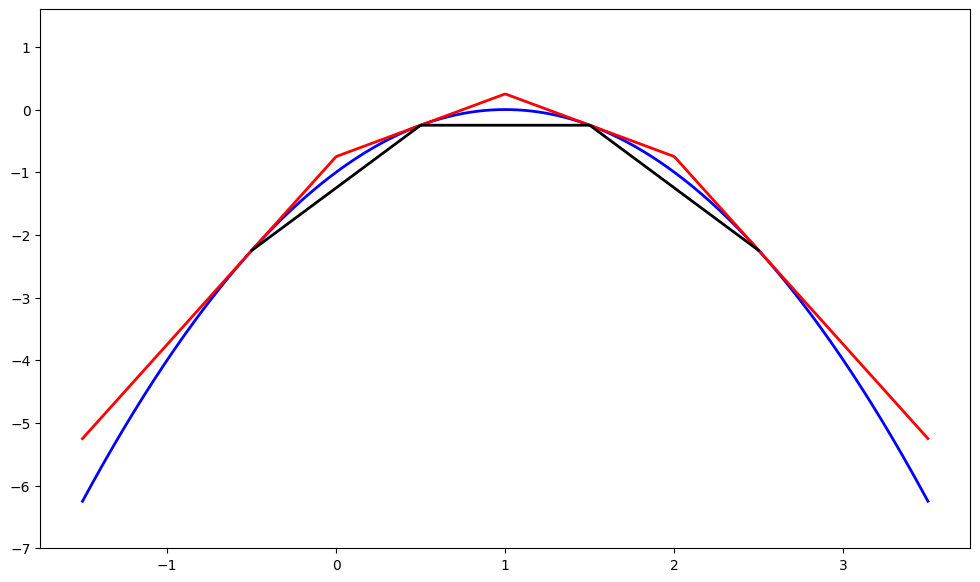

In [5]:
# Visualizamos los resultados

plt.figure(figsize=(12, 7))

# Rango de x para graficar las funciones
x_plot = np.linspace(-1.5, 3.5, 500)

# Graficamos el ln de la PDF objetivo
plt.plot(x_plot, ln_target_pdf(x_plot), color='blue', linewidth=2)
plt.plot(x_plot, ln_envelope_pdf(x_plot, x_nodes, y_nodes, dy_nodes), color='red', linewidth=2)
plt.plot(x_plot, squeezing_function(x_plot, x_nodes, y_nodes), color='black', linewidth=2)

plt.ylim(-7, 1.6)

plt.savefig("RECHAZO_ADAPTATIVO_1.pdf")

plt.show()

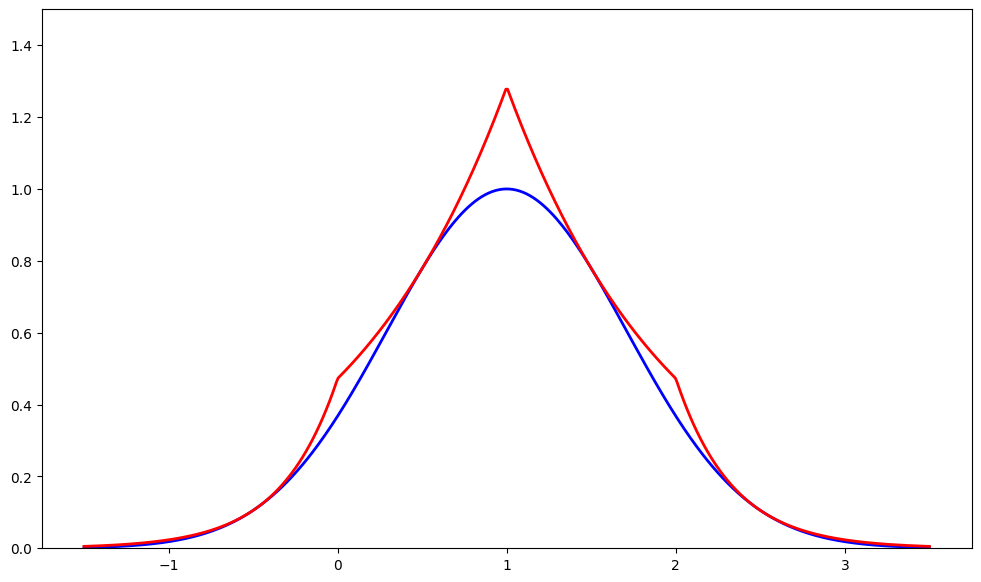

In [6]:
# Visualizamos los resultados

plt.figure(figsize=(12, 7))

# Rango de x para graficar las funciones
x_plot = np.linspace(-1.5, 3.5, 500)

# Graficamos la PDF objetivo
plt.plot(x_plot, target_pdf(x_plot), color='blue', linewidth=2)
plt.plot(x_plot, np.exp(ln_envelope_pdf(x_plot, x_nodes, y_nodes, dy_nodes)), color='red', linewidth = 2)

plt.ylim(0, 1.5)

plt.savefig("RECHAZO_ADAPTATIVO_2.pdf")
plt.show()

In [8]:
from google.colab import files

files.download("RECHAZO_ADAPTATIVO_1.pdf")
files.download("RECHAZO_ADAPTATIVO_2.pdf")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>